In [9]:
# Task 1  —  Vectorize It
# PILLAR: NUMPY FUNDAMENTALS

import numpy as np
product_prices = [10,65,75,85,95,105,115,123,134,135,156,167,189,190,124,890,567,431,231,21]
tax_prices = []
for i in product_prices:
    tax_prices.append(i+(i*0.08))
print(tax_prices)
#Boolean masking
numpy_arr = np.array(product_prices)
tax_numpy_arr = numpy_arr+numpy_arr*0.08
print(tax_numpy_arr)

#bool_arr = tax_numpy_arr>50
print(tax_numpy_arr[tax_numpy_arr>50])

#column and row sum,
arr = np.array([[1,2,3,4],[5,6,7,8],[9,10,11,12],[13,14,15,16]])
row_sum = arr.sum(axis=1)
print("Row sum :",row_sum)
col_sum = arr.sum(axis=0)
print("Column sum : ",col_sum)

[10.8, 70.2, 81.0, 91.8, 102.6, 113.4, 124.2, 132.84, 144.72, 145.8, 168.48, 180.36, 204.12, 205.2, 133.92, 961.2, 612.36, 465.48, 249.48, 22.68]
[ 10.8   70.2   81.    91.8  102.6  113.4  124.2  132.84 144.72 145.8
 168.48 180.36 204.12 205.2  133.92 961.2  612.36 465.48 249.48  22.68]
[ 70.2   81.    91.8  102.6  113.4  124.2  132.84 144.72 145.8  168.48
 180.36 204.12 205.2  133.92 961.2  612.36 465.48 249.48]
Row sum : [10 26 42 58]
Column sum :  [28 32 36 40]


In [52]:
#Task 2  —  Load & Explore
#1.	Read the CSV into a DataFrame with pd.read_csv() and print df.info() and df.describe().
import pandas as pd
data = pd.DataFrame({
    'name': ['Vinaya','Varshith','Aishu','Vaishu','Prasanna','Ajay','Vinay','Anvesh','Imran','Bharath','Vignesh','sunandhan','Bob','Alice','John Doe' ],
     'department': ['HR', 'Finance', 'IT', 'Sales', 'HR', 'Finance', 'IT' ,'Sales', 'HR', 'Finance', 'IT' ,'Sales','HR', 'Finance', 'Sales'],
      'salary': [600000, 700000, 1200000, 800000,600000,700000,1200000,800000,600000,700000,1200000,800000,600000,700000,1200000],
      'experience' : [4,5,6,7,2,4,7,9,10,4,7,3,9,14,2]
})
employees = data.to_csv('employees.csv',index=False)
df = pd.read_csv('employees.csv')
employees = data
employees.loc[len(employees)] = ['Rohit', 'Marketing', 850000, 5]

print(df.info())
print()
print(df.describe())
print()
#2.	Filter the DataFrame to a single department using boolean indexing, and separately using .query().
it_employees = df.query("department == 'IT'")
print(it_employees)
print()
#3.	Group by department and compute the average salary and headcount per department using a single .agg(...) call with named results.
group = df.groupby('department').agg(
    average_salary=('salary','mean'),
    head_count = ('name','count') 
)
print(group)
print(type(employees))
print(employees)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        15 non-null     object
 1   department  15 non-null     object
 2   salary      15 non-null     int64 
 3   experience  15 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 612.0+ bytes
None

             salary  experience
count  1.500000e+01   15.000000
mean   8.266667e+05    6.200000
std    2.433888e+05    3.320929
min    6.000000e+05    2.000000
25%    6.500000e+05    4.000000
50%    7.000000e+05    6.000000
75%    1.000000e+06    8.000000
max    1.200000e+06   14.000000

       name department   salary  experience
2     Aishu         IT  1200000           6
6     Vinay         IT  1200000           7
10  Vignesh         IT  1200000           7

            average_salary  head_count
department                            
Finance           700000.0           4
HR            

In [58]:
# #Task 3  —  Join the Data
# PILLAR: MERGING & MISSING DATA
# Objective: Merge DataFrames and handle missing data sensibly
#1.	Merge your employees DataFrame from Task 2 with departments on the department column using an inner join.
departments = pd.DataFrame({
    'department':['HR', 'Finance', 'IT', 'Sales'],
    'department_budget':[50000,400000,300000,800000]
})
merged_df =pd.merge(employees,departments, on='department',how='inner')
print(merged_df)
print()
#employees.loc[len(employees)] = ['Rohit', 'Marketing', 850000, 5]
#2.	Add at least one employee whose department does NOT exist in the departments table, then redo the merge as a left join — observe the resulting NaN values.
left_join = pd.merge(employees,departments, on ='department',how='left')
print("-----------------------------------------")
print(left_join)


print()
#3.	Introduce at least two missing values into your salary or years_experience column (e.g. using numpy.nan), then detect them with .isna().sum().
print("_________________________________________________")
employees.loc[2,'salary']=np.nan
employees.loc[5,'experience']=np.nan
print(employees)
print(employees.isna().sum())
print()
#4.	Handle the missing values with a justified choice: either drop those rows or fill them (e.g. with the column mean) — write a one-sentence comment explaining why you chose that approach for this specific column.
employees['salary'] = employees['salary'].fillna(employees['salary'].mean())
employees['experience'] = employees['experience'].fillna(employees['experience'].mean())
print(employees)
print(employees.isna().sum())

         name department        salary  experience  department_budget
0      Vinaya         HR  6.000000e+05    4.000000              50000
1    Varshith    Finance  7.000000e+05    5.000000             400000
2       Aishu         IT  8.033333e+05    6.000000             300000
3      Vaishu      Sales  8.000000e+05    7.000000             800000
4    Prasanna         HR  6.000000e+05    2.000000              50000
5        Ajay    Finance  7.000000e+05    6.266667             400000
6       Vinay         IT  1.200000e+06    7.000000             300000
7      Anvesh      Sales  8.000000e+05    9.000000             800000
8       Imran         HR  6.000000e+05   10.000000              50000
9     Bharath    Finance  7.000000e+05    4.000000             400000
10    Vignesh         IT  1.200000e+06    7.000000             300000
11  sunandhan      Sales  8.000000e+05    3.000000             800000
12        Bob         HR  6.000000e+05    9.000000              50000
13      Alice    Fin

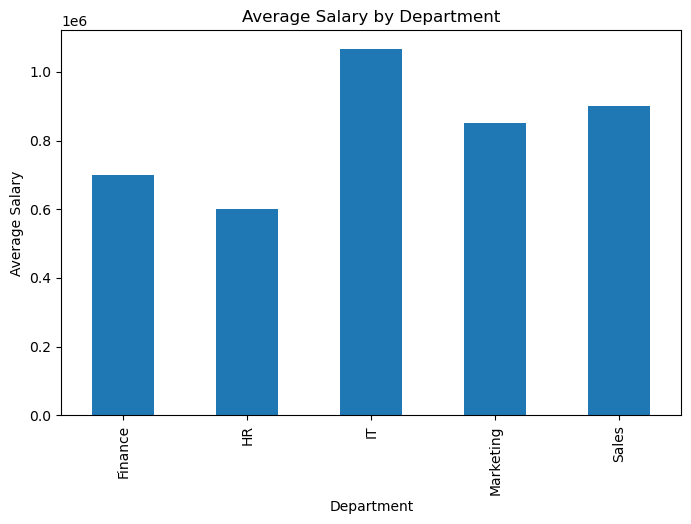

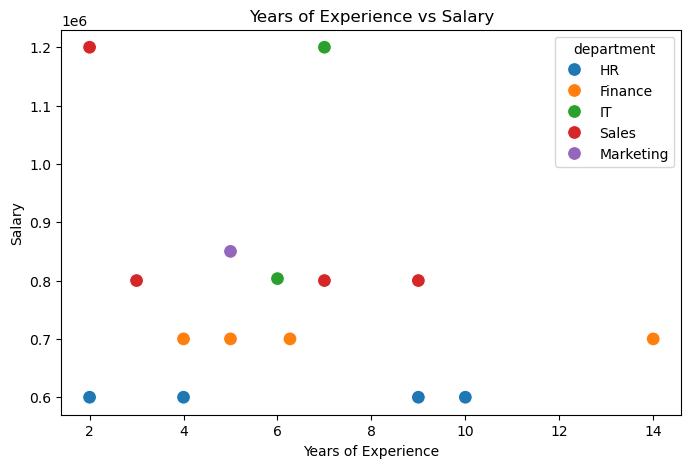

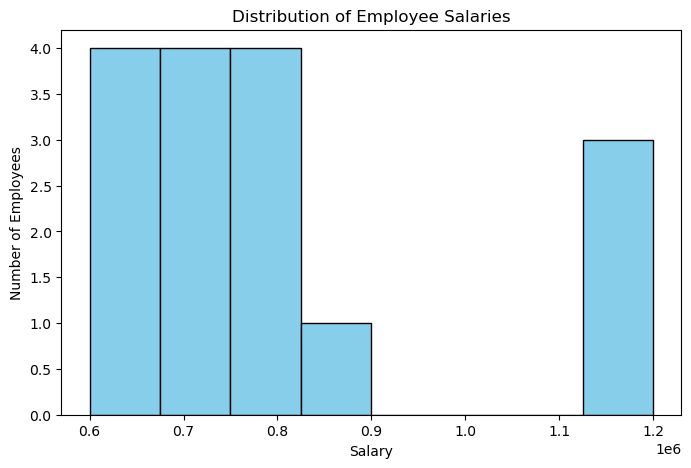

In [66]:
#Task 4  —  Tell a Story
#1.	Create a bar chart comparing average salary across departments.
import matplotlib.pyplot as plt
avg_sal = employees.groupby('department')['salary'].mean()
plt.figure(figsize=(8, 5))
avg_sal.plot(kind='bar')
plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')
plt.show()
#2.	Create a scatter plot of years_experience vs. salary, colored (hue) by department.
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=employees,
    x='experience',
    y='salary',
    hue='department',
    s=100
)

plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()
plt.figure(figsize=(8, 5))
#3.	Create a histogram showing the distribution of salaries across all employees.

plt.hist(
    employees['salary'],
    bins=8,
    color='skyblue',
    edgecolor='black'
)

plt.title('Distribution of Employee Salaries')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')
plt.show()

In [ ]:
#Task 5  —  Consolidation Reflection
